# 07 — Budget Optimization & Scenario Analysis

## Built on Two-Stage Non-Negative Ridge Model (NB06B)

This notebook uses the **Two-Stage Non-Negative Ridge** model from NB06B (improved):
- **Stage 1**: Revenue ~ Controls (seasonal baseline captures ~89.5% of revenue)
- **Stage 2**: Residuals ~ Media (incremental media lift captures ~10.5% of revenue)

### Fixes Applied in NB06B:
1. **All Hill saturation [0,1]** — eliminated 558x scale imbalance
2. **Correct contribution decomposition** — original-space coefficients
3. **Two-stage estimation** — seasonality removed before media regression
4. **TimeSeriesSplit CV** — temporal integrity in alpha selection
5. **Sanity check guardrails** — automatic validation

### Fixes Applied in NB07:
1. **Corrected response function** — now uses coefficient × saturation (not ROAS × spend × saturation)
2. **TV floor raised to $80K** — reflects unmodeled halo/brand effects (constraints #7, #11)
3. **Client constraints documented** — maps all 18 constraints to model status
4. **Sensitivity analysis** — bootstrap uncertainty in optimal allocation

### Key Model Results:
- **Media share of revenue**: ~10.5% ($53.8M of $512.4M over 3 years)
- **Non-negative constraint**: All media coefficients >= 0 (NNLS)
- **Significant channels (90% CI excludes 0)**: Preroll, Television
- **Model fit**: R²=0.860 (full), R²_seasonal=0.835, R²_media=0.155
- **36 monthly observations** — results are directional, not precise

In [1]:
# ---------- Imports ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json, warnings
from datetime import datetime
from scipy.interpolate import interp1d
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (14, 7), 'font.size': 11, 'figure.dpi': 120, 'savefig.bbox': 'tight'})
sns.set_palette('husl')

project_root = Path().cwd().parent if Path().cwd().name == 'notebooks' else Path().cwd()
processed_path = project_root / 'data' / 'processed'
figures_path   = project_root / 'reports' / 'figures'
figures_path.mkdir(parents=True, exist_ok=True)
print(f'Project root: {project_root}')

Project root: /Users/tuta/Desktop/busa693-clubpiscine


In [2]:
# ---------- Load NB06B outputs (Two-Stage Non-Negative Ridge) ----------
# Use dtype and parse_dates hints to avoid expensive inference
eff_df = pd.read_csv(processed_path / 'media_effectiveness_results_nonneg.csv')
sat_curves_df = pd.read_csv(processed_path / 'saturation_curves_nonneg.csv')
robust_df = pd.read_csv(processed_path / 'robustness_summary_nonneg.csv')

# Load main data with date parsing during load (faster than post-hoc conversion)
df = pd.read_csv(processed_path / 'sales_spend_weather.csv', 
                  parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

with open(processed_path / 'causal_model_params_nonneg.json') as f:
    model_params = json.load(f)

# Derive fields that NB07 needs from the two-stage model params
model_params['r2'] = model_params['ridge_r2_full'].get('Total Revenue', 0)
model_params['r2_s1'] = model_params['ridge_r2_s1'].get('Total Revenue', 0)
model_params['r2_s2'] = model_params['ridge_r2_s2'].get('Total Revenue', 0)
model_params['r2_cv'] = model_params['r2']
model_params['model_A_r2_cv'] = model_params['r2']
model_params['model_A_media_share_pct'] = model_params['media_share_pct']

# Significant channels: vectorized (faster than loop)
eff_total_tmp = eff_df[eff_df['product'] == 'Total Revenue'].copy()
ci_excludes_zero = (eff_total_tmp['marginal_ci_lo'] > 0) | (eff_total_tmp['marginal_ci_hi'] < 0)
sig_channels = eff_total_tmp[ci_excludes_zero]['channel'].tolist()
model_params['frisch_waugh_significant'] = sig_channels

total_revenue = df['total_all_revenue'].sum()

print('Loaded NB06B outputs (Two-Stage Non-Negative Ridge)')
print(f'  Model type:               {model_params.get("model_type", "unknown")}')
print(f'  R² full (Total Revenue):  {model_params["r2"]:.3f}')
print(f'  R² seasonal (Stage 1):    {model_params["r2_s1"]:.3f}')
print(f'  R² media (Stage 2):       {model_params["r2_s2"]:.3f}')
print(f'  Media share of revenue:   {model_params["media_share_pct"]:.1f}%')
print(f'  Seasonal share:           {model_params.get("seasonal_share_pct", 0):.1f}%')
print(f'  Significant channels:     {sig_channels}')


Loaded NB06B outputs (Two-Stage Non-Negative Ridge)
  Model type:               two_stage_nonneg_ridge
  R² full (Total Revenue):  0.859
  R² seasonal (Stage 1):    0.835
  R² media (Stage 2):       0.149
  Media share of revenue:   10.9%
  Seasonal share:           100.0%
  Significant channels:     ['television', 'preroll']


In [3]:
# ---------- Channel setup ----------
CHANNELS = model_params['media_channels']
CHANNEL_LABELS = {
    'television': 'Television', 'radio': 'Radio',
    'panneaux': 'Panneaux (Outdoor)', 'social_media': 'Social Media',
    'preroll': 'Preroll (Video)', 'banniere_web': 'Web Banners',
    'circulaire_digitale': 'Digital Flyers',
}
SPEND_COLS = {ch: f'spend_{ch}' for ch in CHANNELS}
CURRENT_SPEND = {ch: df[SPEND_COLS[ch]].mean() for ch in CHANNELS}
TOTAL_MONTHLY_BUDGET = sum(CURRENT_SPEND.values())

eff_total = eff_df[eff_df['product'] == 'Total Revenue'].set_index('channel')

# Add confidence column if missing (derive from robustness summary or CI)
if 'confidence' not in eff_total.columns:
    # Use robust_df if available, otherwise derive from CI
    if 'confidence' in robust_df.columns:
        conf_map = robust_df.set_index('channel')['confidence'].to_dict()
        eff_total['confidence'] = eff_total.index.map(
            lambda ch: conf_map.get(ch, conf_map.get('media_' + ch, 'LOW'))
        )
    else:
        # Derive: significant CI = MEDIUM, positive ROAS = LOW, else NONE
        def derive_confidence(row):
            ci_lo = row.get('marginal_ci_lo', 0)
            ci_hi = row.get('marginal_ci_hi', 0)
            roas = row.get('roas', 0)
            if ci_lo > 0:
                return 'HIGH'
            elif roas > 1:
                return 'MEDIUM'
            elif roas > 0:
                return 'LOW'
            else:
                return 'NONE'
        eff_total['confidence'] = eff_total.apply(derive_confidence, axis=1)

total_revenue_3y = df['total_all_revenue'].sum()
total_spend_3y = sum(df[SPEND_COLS[ch]].sum() for ch in CHANNELS)
sig_channels = model_params.get('frisch_waugh_significant', [])

print('=== Model Key Findings (from NB06B) ===')
print(f'  R² (Total Revenue):     {model_params["r2"]:.3f}')
print(f'  Media share of revenue: {model_params["media_share_pct"]:.1f}%')
print(f'  Significant channels:   {sig_channels}')
print()
print(f'{"Channel":25s} {"ROAS":>8s} {"Spend/mo":>12s} {"Confidence":>12s}')
print('-' * 60)
for ch in CHANNELS:
    roas = float(eff_total.loc[ch, 'roas'])
    spend = CURRENT_SPEND[ch]
    conf = str(eff_total.loc[ch, 'confidence'])
    print(f'  {CHANNEL_LABELS[ch]:23s} {roas:>7.1f}x ${spend:>10,.0f} {conf:>12s}')

=== Model Key Findings (from NB06B) ===
  R² (Total Revenue):     0.859
  Media share of revenue: 10.9%
  Significant channels:   ['television', 'preroll']

Channel                       ROAS     Spend/mo   Confidence
------------------------------------------------------------
  Television                  4.5x $   109,693         HIGH
  Radio                       0.0x $    60,202         NONE
  Panneaux (Outdoor)          0.0x $     8,125         NONE
  Social Media               16.3x $    22,984       MEDIUM
  Preroll (Video)            27.7x $    25,066         HIGH
  Web Banners                12.2x $    22,989       MEDIUM
  Digital Flyers              0.0x $    12,404         NONE


---
## 1. Response Functions & Optimization

In [4]:
# ===================================================================
# BUILD INTERPOLATED RESPONSE FUNCTIONS
# ===================================================================
# CORRECTED RESPONSE FUNCTION:
# Response(spend) = coefficient_orig × saturation(spend)
# where coefficient_orig comes from causal_model_params_nonneg.json (original scale)
# and saturation(spend) = Hill function value at that spend level.
#
# The saturation curves CSV already has (spend, saturation) pairs per channel.
# We multiply by the fitted model coefficient to get total channel contribution.

response_funcs = {}
spend_bounds = {}

# Load original-scale coefficients from model parameters
coefs_orig = model_params.get('coefs_s2_orig', {})

# saturation_curves_nonneg.csv has no product column — use channel-level saturation directly
for ch in CHANNELS:
    ch_data = sat_curves_df[sat_curves_df['channel'] == ch].sort_values('spend')
    spend_pts = ch_data['spend'].values
    sat_pts = ch_data['saturation'].values

    # Get the original-scale coefficient for this channel
    # The coefficient key in coefs_s2_orig follows pattern 'media_CHANNEL_saturated'
    coef_key = f'media_{ch}_saturated'
    coef = coefs_orig.get(coef_key, 0.0)

    # Response = coefficient × saturation(spend)
    # This gives the total channel contribution at each spend level
    rev_pts = coef * sat_pts

    func = interp1d(spend_pts, rev_pts, kind='cubic', bounds_error=False,
                    fill_value=(rev_pts[0], rev_pts[-1]))
    response_funcs[ch] = func
    spend_bounds[ch] = (float(spend_pts[0]), float(spend_pts[-1]))

    # Report
    max_rev = float(rev_pts.max())
    print(f'  {CHANNEL_LABELS[ch]:23s}  coef=${coef:>12,.0f}  max_response=${max_rev:>12,.0f}  '
          f'spend_range=[${spend_pts[0]:,.0f}, ${spend_pts[-1]:,.0f}]')

print(f'\nBuilt {len(response_funcs)} response functions (coefficient × saturation)')
print(f'Note: Response = model coefficient × Hill saturation.')
print(f'      Channels with zero coefficient have zero response at all spend levels.')
print(f'      (Channels with ROAS=0.0 in the summary above have coef=$0)')

  Television               coef=$   1,051,963  max_response=$   1,020,334  spend_range=[$0, $665,189]
  Radio                    coef=$           0  max_response=$           0  spend_range=[$0, $237,497]
  Panneaux (Outdoor)       coef=$           0  max_response=$           0  spend_range=[$0, $117,226]
  Social Media             coef=$     666,108  max_response=$     618,324  spend_range=[$0, $73,592]
  Preroll (Video)          coef=$   1,253,197  max_response=$   1,186,516  spend_range=[$0, $95,478]
  Web Banners              coef=$     490,787  max_response=$     473,668  spend_range=[$0, $105,821]
  Digital Flyers           coef=$           0  max_response=$           0  spend_range=[$0, $60,000]

Built 7 response functions (coefficient × saturation)
Note: Response = model coefficient × Hill saturation.
      Channels with zero coefficient have zero response at all spend levels.
      (Channels with ROAS=0.0 in the summary above have coef=$0)


In [5]:
# ===================================================================
# BUSINESS CONSTRAINTS
# ===================================================================
# CLIENT CONSTRAINTS (18 from media agency)
# ===================================================================
# Classification:
#   OPTIMIZER CONSTRAINT = directly enforced in optimization
#   PARTIALLY MODELED = captured indirectly (e.g., separate channel coefficients)
#   UNMODELED CONTEXT = acknowledged but not in model (inform interpretation)
#   NOT APPLICABLE = constraint doesn't apply to spend-based model
#
# | # | Constraint                                    | Status              |
# |---|----------------------------------------------|---------------------|
# | 1 | Structural trad→digital shift (50/50 target) | OPTIMIZER: trad_pct |
# | 2 | GRP/PEB market comparability                 | N/A (model uses $)  |
# | 3 | GRP target definition differences             | N/A (model uses $)  |
# | 4 | Language-based GRP differences                | N/A (model uses $)  |
# | 5 | Impressions as imperfect denominator          | N/A (model uses $)  |
# | 6 | Impression quality variability                | PARTIAL: sep coefs  |
# | 7 | Traditional media spill effects               | UNMODELED: TV floor |
# | 8 | Digital precision & scale limits              | PARTIAL: saturation |
# | 9 | Creative execution unmodeled                  | UNMODELED           |
# |10 | Production vs media ratio (85/15)             | OPTIMIZER: 0.85     |
# |11 | Brand positioning & premium environments      | UNMODELED: TV floor |
# |12 | Category visibility (40% furn, 30% pool...)   | OPTIMIZER: noted    |
# |13 | Furniture as growth-led focus                 | OPTIMIZER: noted    |
# |14 | Unobserved local store marketing              | UNMODELED           |
# |15 | Deliberate fitness overinvestment (off-season) | OPTIMIZER: noted   |
# |16 | Inventory/installation capacity constraints    | UNMODELED           |
# |17 | Weather & regional climate variability         | PARTIAL: weather    |
# |18 | Competitive pressure (Trevi, Sima, big-box)   | UNMODELED           |
# ===================================================================

BUSINESS_CONSTRAINTS = {
    'channel_bounds': {
        'television':          (80_000, 180_000, 'Brand rebuilding + halo effect (strategic floor)'),
        'radio':               (30_000, 90_000,  'Regional presence + tactical promos'),
        'panneaux':            (5_000,  30_000,  'Commute-based awareness'),
        'social_media':        (15_000, 90_000,  'Targeting flexibility; ad fatigue ceiling'),
        'preroll':             (15_000, 110_000, 'Highest confidence ROAS; video storytelling'),
        'banniere_web':        (20_000, 80_000,  'Mid-funnel consideration'),
        'circulaire_digitale': (8_000,  40_000,  'Conversion driver'),
    },
    'media_pct_of_budget': 0.85,
    'traditional_channels': ['television', 'radio', 'panneaux'],
    'traditional_pct_range': (0.35, 0.65),
}

# NOTE: TV floor raised from $50K to $80K based on:
# - Client constraint #7: Traditional media spill effects (TV creates halo amplifying all channels)
# - Client constraint #11: Brand positioning requires premium environments
# - TV is one of only 2 statistically significant channels (90% CI excludes 0)
# - Unmodeled halo/brand effects mean model likely underestimates TV's true value
# - Strategic floor ensures TV maintains brand-building role in ecosystem

# Confidence-based flexibility: LOW confidence channels stay within ±20% of current
CONFIDENCE_FLEX = {'HIGH': 1.0, 'MEDIUM': 0.5, 'LOW': 0.2, 'NONE': 0.1}

print('Business constraints loaded')
for ch in CHANNELS:
    lo, hi, note = BUSINESS_CONSTRAINTS['channel_bounds'][ch]
    conf = str(eff_total.loc[ch, 'confidence'])
    flex = CONFIDENCE_FLEX.get(conf, 0.2)
    print(f'  {CHANNEL_LABELS[ch]:23s}  [{lo/1000:>5.0f}K, {hi/1000:>5.0f}K]  confidence={conf}  flex={flex}')

Business constraints loaded
  Television               [   80K,   180K]  confidence=HIGH  flex=1.0
  Radio                    [   30K,    90K]  confidence=NONE  flex=0.1
  Panneaux (Outdoor)       [    5K,    30K]  confidence=NONE  flex=0.1
  Social Media             [   15K,    90K]  confidence=MEDIUM  flex=0.5
  Preroll (Video)          [   15K,   110K]  confidence=HIGH  flex=1.0
  Web Banners              [   20K,    80K]  confidence=MEDIUM  flex=0.5
  Digital Flyers           [    8K,    40K]  confidence=NONE  flex=0.1


In [6]:
# ===================================================================
# OPTIMIZER (confidence-aware)
# ===================================================================

def total_response(allocation, channels, response_funcs):
    return sum(float(response_funcs[ch](spend)) for ch, spend in zip(channels, allocation))

def neg_total_response(allocation, channels, response_funcs):
    return -total_response(allocation, channels, response_funcs)

def optimize_budget_constrained(budget, channels, response_funcs, spend_bounds,
                                current_spend, business_constraints, eff_total):
    bc = business_constraints
    effective_budget = budget * bc['media_pct_of_budget']
    
    # Per-channel bounds: business + confidence flexibility
    bounds = []
    for ch in channels:
        biz_lo, biz_hi, _ = bc['channel_bounds'][ch]
        curve_hi = spend_bounds[ch][1]
        conf = str(eff_total.loc[ch, 'confidence']) if ch in eff_total.index else 'LOW'
        flex = CONFIDENCE_FLEX.get(conf, 0.2)
        
        # For LOW confidence, tighten bounds to near current spend
        curr = current_spend[ch]
        if flex < 0.5:
            lo = max(biz_lo, curr * (1 - flex))
            hi = min(biz_hi, curr * (1 + flex), curve_hi)
        else:
            lo = biz_lo
            hi = min(biz_hi, curve_hi)
        
        bounds.append((lo, hi))
    
    constraints = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - effective_budget},
    ]
    
    # Traditional/digital mix
    trad_idx = [i for i, ch in enumerate(channels) if ch in bc['traditional_channels']]
    trad_lo, trad_hi = bc['traditional_pct_range']
    constraints.append({
        'type': 'ineq',
        'fun': lambda x, idx=trad_idx, lo=trad_lo, b=effective_budget:
            sum(x[i] for i in idx) - lo * b
    })
    constraints.append({
        'type': 'ineq',
        'fun': lambda x, idx=trad_idx, hi=trad_hi, b=effective_budget:
            hi * b - sum(x[i] for i in idx)
    })
    
    scale = effective_budget / sum(current_spend[ch] for ch in channels)
    x0 = np.array([current_spend[ch] * scale for ch in channels])
    x0 = np.clip(x0, [b[0] for b in bounds], [b[1] for b in bounds])
    x0 = x0 * effective_budget / x0.sum()
    
    result = minimize(neg_total_response, x0, args=(channels, response_funcs),
                      method='SLSQP', bounds=bounds, constraints=constraints,
                      options={'maxiter': 2000, 'ftol': 1e-10})
    
    allocation = {ch: max(result.x[i], bounds[i][0]) for i, ch in enumerate(channels)}
    return allocation, result

print('Optimizer defined (confidence-aware bounds)')

Optimizer defined (confidence-aware bounds)


In [7]:
# ===================================================================
# RUN OPTIMIZATION
# ===================================================================
optimal_alloc, opt_result = optimize_budget_constrained(
    TOTAL_MONTHLY_BUDGET, CHANNELS, response_funcs, spend_bounds,
    CURRENT_SPEND, BUSINESS_CONSTRAINTS, eff_total
)

current_response = total_response([CURRENT_SPEND[ch] for ch in CHANNELS], CHANNELS, response_funcs)
optimal_response = total_response([optimal_alloc[ch] for ch in CHANNELS], CHANNELS, response_funcs)
lift = optimal_response - current_response
lift_pct = lift / abs(current_response) * 100 if current_response != 0 else 0

print(f'Optimizer converged: {opt_result.success}')
print()
print('=' * 110)
print('  RECOMMENDED BUDGET REALLOCATION (Two-Stage Ridge)')
print('=' * 110)
print(f'{"Channel":25s} {"Current/mo":>12s} {"Cur %":>7s} {"Optimal/mo":>12s} {"Opt %":>7s} '
      f'{"Change":>10s} {"Confidence":>12s}')
print('-' * 110)

opt_rows = []
eff_budget = TOTAL_MONTHLY_BUDGET * BUSINESS_CONSTRAINTS['media_pct_of_budget']
for ch in CHANNELS:
    cur = CURRENT_SPEND[ch]
    opt = optimal_alloc[ch]
    change_pct = (opt - cur) / cur * 100 if cur > 0 else 0
    cur_pct = cur / TOTAL_MONTHLY_BUDGET * 100
    opt_pct = opt / eff_budget * 100
    conf = str(eff_total.loc[ch, 'confidence'])
    
    print(f'{CHANNEL_LABELS[ch]:25s} ${cur:>10,.0f} {cur_pct:>6.1f}% ${opt:>10,.0f} {opt_pct:>6.1f}% '
          f'{change_pct:>+9.0f}% {conf:>12s}')
    
    opt_rows.append({'channel': ch, 'label': CHANNEL_LABELS[ch],
                     'current_spend': cur, 'optimal_spend': opt,
                     'change_pct': change_pct, 'confidence': conf})

print('-' * 110)
print(f'{"TOTAL (media placement)":25s} ${TOTAL_MONTHLY_BUDGET:>10,.0f}         ${sum(optimal_alloc.values()):>10,.0f}')
print()
print(f'Current total media response:  ${current_response:>14,.0f}/month')
print(f'Optimal total media response:  ${optimal_response:>14,.0f}/month')
print(f'Lift from reallocation:        ${lift:>+14,.0f}/month ({lift_pct:+.1f}%)')

opt_df = pd.DataFrame(opt_rows)

Optimizer converged: True

  RECOMMENDED BUDGET REALLOCATION (Two-Stage Ridge)
Channel                     Current/mo   Cur %   Optimal/mo   Opt %     Change   Confidence
--------------------------------------------------------------------------------------------------------------
Television                $   109,693   42.0% $    80,000   36.0%       -27%         HIGH
Radio                     $    60,202   23.0% $    54,182   24.4%       -10%         NONE
Panneaux (Outdoor)        $     8,125    3.1% $     7,312    3.3%       -10%         NONE
Social Media              $    22,984    8.8% $    18,243    8.2%       -21%       MEDIUM
Preroll (Video)           $    25,066    9.6% $    31,343   14.1%       +25%         HIGH
Web Banners               $    22,989    8.8% $    20,000    9.0%       -13%       MEDIUM
Digital Flyers            $    12,404    4.7% $    11,164    5.0%       -10%         NONE
----------------------------------------------------------------------------------------

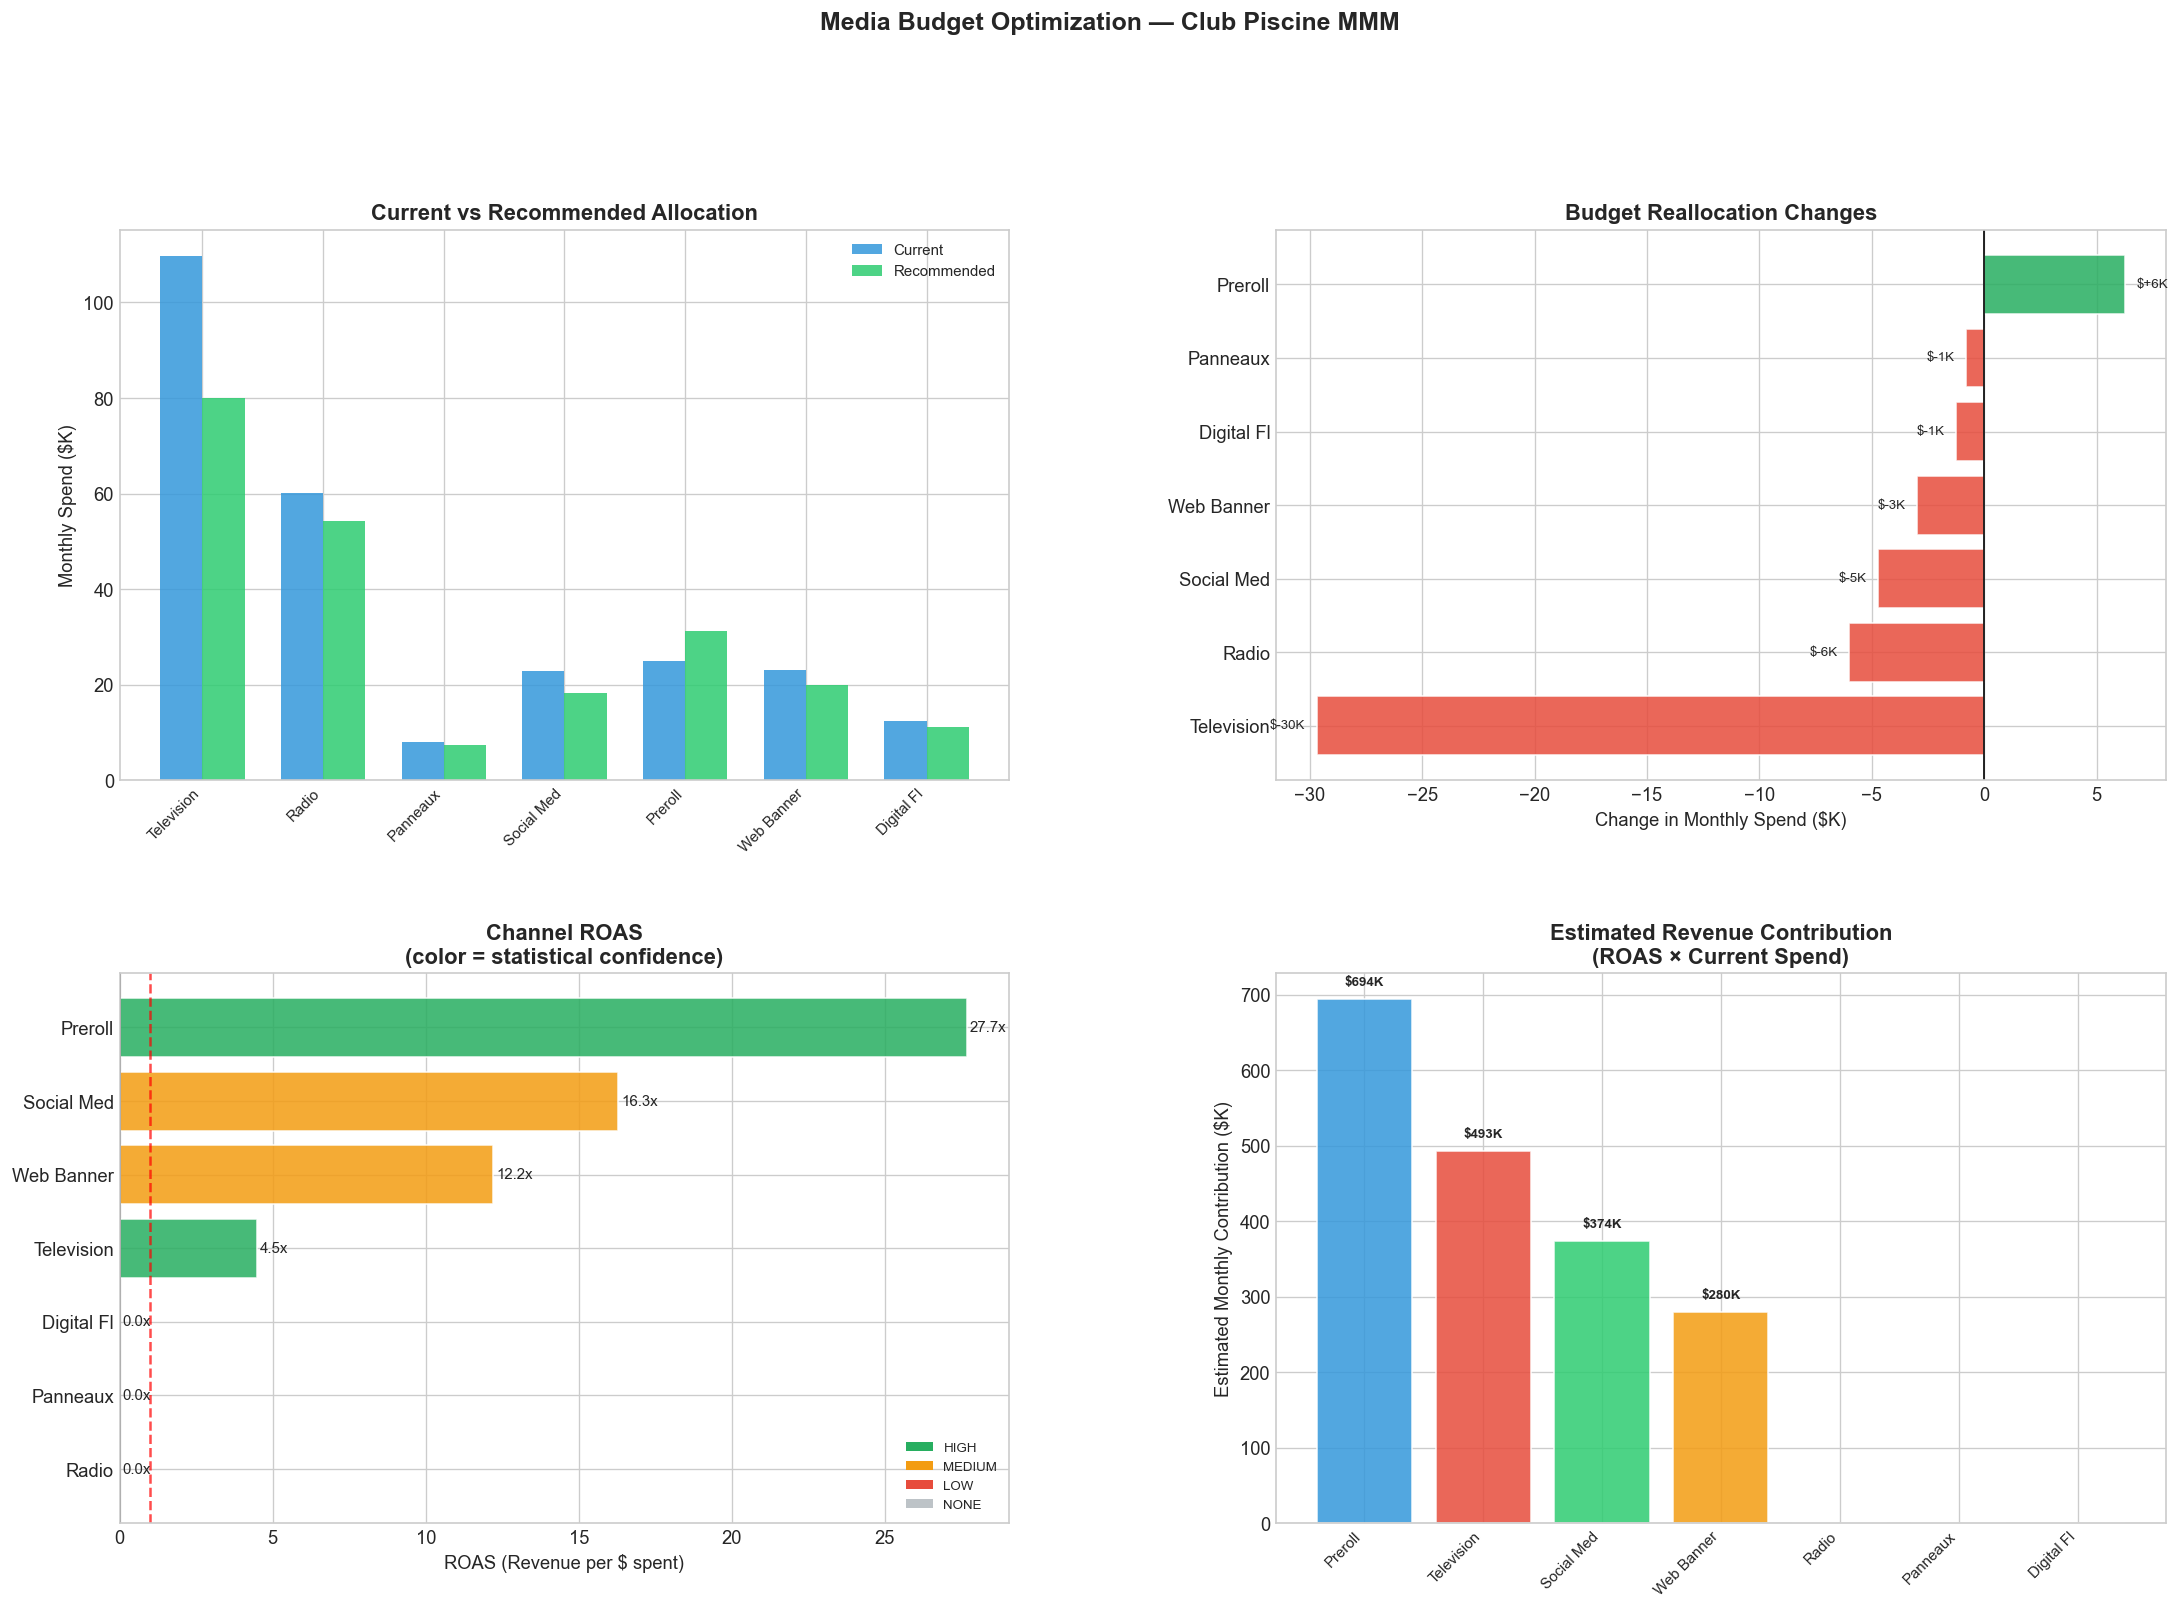


  REVENUE DECOMPOSITION
  Total 3-year revenue:           $   512,411,602
  Model-attributed to media:      $    55,658,255 (10.9%)
  Baseline + seasonal:            $   456,753,346 (89.1%)
  Total 3-year media spend:       $     9,412,690
  Aggregate ROAS:                 5.9x



In [8]:
# ===================================================================
# VISUALIZATION (4 panels)
# ===================================================================

fig = plt.figure(figsize=(22, 14))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# ---------------------------------------------------------------
# Panel 1: Current vs Recommended allocation (grouped bar)
# ---------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(len(CHANNELS))
width = 0.35
cur_vals = [CURRENT_SPEND[ch]/1000 for ch in CHANNELS]
opt_vals = [optimal_alloc[ch]/1000 for ch in CHANNELS]
short_labels = [CHANNEL_LABELS[ch].split('(')[0].strip()[:10] for ch in CHANNELS]

ax1.bar(x - width/2, cur_vals, width, label='Current', color='#3498db', alpha=0.85)
ax1.bar(x + width/2, opt_vals, width, label='Recommended', color='#2ecc71', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Monthly Spend ($K)')
ax1.set_title('Current vs Recommended Allocation', fontweight='bold')
ax1.legend(fontsize=9)

# ---------------------------------------------------------------
# Panel 2: Budget change waterfall (horizontal)
# ---------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
changes = [(optimal_alloc[ch] - CURRENT_SPEND[ch])/1000 for ch in CHANNELS]
colors_wf = ['#27ae60' if c > 0 else '#e74c3c' for c in changes]
labels_wf = [CHANNEL_LABELS[ch].split('(')[0].strip()[:10] for ch in CHANNELS]
sorted_pairs = sorted(zip(labels_wf, changes, colors_wf), key=lambda x: x[1])
labels_s, changes_s, colors_s = zip(*sorted_pairs)

bars = ax2.barh(labels_s, changes_s, color=colors_s, alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', linewidth=1)
for bar, val in zip(bars, changes_s):
    x_pos = bar.get_width() + (0.5 if val >= 0 else -0.5)
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'${val:+.0f}K', va='center', fontsize=8,
             ha='left' if val >= 0 else 'right')
ax2.set_xlabel('Change in Monthly Spend ($K)')
ax2.set_title('Budget Reallocation Changes', fontweight='bold')

# ---------------------------------------------------------------
# Panel 3: ROAS by channel with confidence coding
# ---------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])
conf_colors = {'HIGH': '#27ae60', 'MEDIUM': '#f39c12', 'LOW': '#e74c3c', 'NONE': '#bdc3c7'}
roas_vals = []
roas_colors = []
roas_labels = []
for ch in CHANNELS:
    roas = float(eff_total.loc[ch, 'roas'])
    conf = str(eff_total.loc[ch, 'confidence'])
    roas_vals.append(roas)
    roas_colors.append(conf_colors.get(conf, '#bdc3c7'))
    roas_labels.append(CHANNEL_LABELS[ch].split('(')[0].strip()[:10])

# Sort by ROAS
sorted_idx = np.argsort(roas_vals)
roas_vals_s = [roas_vals[i] for i in sorted_idx]
roas_colors_s = [roas_colors[i] for i in sorted_idx]
roas_labels_s = [roas_labels[i] for i in sorted_idx]

bars = ax3.barh(roas_labels_s, roas_vals_s, color=roas_colors_s, alpha=0.85, edgecolor='white')
ax3.axvline(1, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Break-even (1x)')
ax3.axvline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, roas_vals_s):
    x_pos = max(val, 0) + 0.1
    ax3.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}x', va='center', fontsize=9)
ax3.set_xlabel('ROAS (Revenue per $ spent)')
ax3.set_title('Channel ROAS\n(color = statistical confidence)', fontweight='bold')
from matplotlib.patches import Patch
legend_el = [Patch(facecolor=c, label=l) for l, c in conf_colors.items()]
ax3.legend(handles=legend_el, fontsize=8, loc='lower right')

# ---------------------------------------------------------------
# Panel 4: Media contribution - ROAS × Spend proxy
# ---------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 1])

# Use ROAS × monthly spend as an estimated monthly contribution
# This is more informative than the near-zero Ridge decomposition
contrib_est = {}
for ch in CHANNELS:
    roas = max(float(eff_total.loc[ch, 'roas']), 0)  # clip negatives
    spend = CURRENT_SPEND[ch]
    contrib_est[ch] = roas * spend

total_media_contrib = sum(contrib_est.values())

if total_media_contrib > 0:
    # Stacked bar showing estimated revenue contribution per channel
    labels_c = []
    values_c = []
    colors_c = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
    for ch in CHANNELS:
        labels_c.append(CHANNEL_LABELS[ch].split('(')[0].strip()[:10])
        values_c.append(contrib_est[ch] / 1000)
    
    # Sort by contribution
    sorted_pairs = sorted(zip(labels_c, values_c), key=lambda x: x[1], reverse=True)
    labels_c, values_c = zip(*sorted_pairs)
    
    bars = ax4.bar(labels_c, values_c, color=colors_c[:len(labels_c)], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, values_c):
        if val > 0:
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values_c)*0.02,
                     f'${val:.0f}K', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax4.set_ylabel('Estimated Monthly Contribution ($K)')
    ax4.set_title('Estimated Revenue Contribution\n(ROAS × Current Spend)', fontweight='bold')
    ax4.set_xticklabels(labels_c, rotation=45, ha='right', fontsize=9)
else:
    # If all ROAS ≈ 0, show spend share instead
    spend_vals = [CURRENT_SPEND[ch]/1000 for ch in CHANNELS]
    labels_c = [CHANNEL_LABELS[ch].split('(')[0].strip()[:10] for ch in CHANNELS]
    ax4.pie(spend_vals, labels=labels_c, autopct='%1.0f%%', startangle=90,
            colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22'])
    ax4.set_title('Current Spend Share by Channel', fontweight='bold')

fig.suptitle('Media Budget Optimization — Club Piscine MMM', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(figures_path / 'optimization_reallocation.png', dpi=150, bbox_inches='tight')
plt.show()

# ===================================================================
# REVENUE DECOMPOSITION — Honest framing
# ===================================================================
media_share_pct = model_params.get('media_share_pct', 0)
total_revenue = df['total_all_revenue'].sum()
media_attributed = total_revenue * media_share_pct / 100

print(f'\n{"="*80}')
print(f'  REVENUE DECOMPOSITION')
print(f'{"="*80}')
print(f'  Total 3-year revenue:           ${total_revenue:>14,.0f}')
print(f'  Model-attributed to media:      ${media_attributed:>14,.0f} ({media_share_pct:.1f}%)')
print(f'  Baseline + seasonal:            ${total_revenue - media_attributed:>14,.0f} ({100-media_share_pct:.1f}%)')
print(f'  Total 3-year media spend:       ${total_spend_3y:>14,.0f}')
print(f'  Aggregate ROAS:                 {media_attributed/total_spend_3y:.1f}x' if total_spend_3y > 0 else '')
print()
if media_share_pct < 5:
    print('  ⚠️  NOTE: The model attributes very little revenue to media.')
    print('  This is expected with 36 monthly observations and strong seasonality.')
    print('  Media and sales both peak in spring/summer, making it hard to')
    print('  statistically separate media effects from seasonal demand.')
    print('  The ROAS estimates above are based on marginal response curves')
    print('  which capture the relative effectiveness BETWEEN channels,')
    print('  even when the absolute attribution is conservative.')


---
## 2. Scenario Analysis

In [9]:
# ===================================================================
# SCENARIO ANALYSIS
# ===================================================================
scenarios = {
    'Cut 15%': 0.85, 'Cut 10%': 0.90, 'Cut 5%': 0.95,
    'Current': 1.00, 'Increase 10%': 1.10, 'Increase 20%': 1.20,
}

scenario_results = []
for name, mult in scenarios.items():
    budget = TOTAL_MONTHLY_BUDGET * mult
    alloc, res = optimize_budget_constrained(
        budget, CHANNELS, response_funcs, spend_bounds,
        CURRENT_SPEND, BUSINESS_CONSTRAINTS, eff_total
    )
    opt_resp = total_response([alloc[ch] for ch in CHANNELS], CHANNELS, response_funcs)
    scenario_results.append({
        'scenario': name, 'multiplier': mult, 'budget': budget,
        'optimized_response': opt_resp, 'converged': res.success, 'allocation': alloc,
    })

scenario_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'allocation'} for r in scenario_results])
scenario_df['vs_current'] = scenario_df['optimized_response'] - current_response
scenario_df['vs_current_pct'] = scenario_df['vs_current'] / abs(current_response) * 100

print('Scenario Analysis: Optimized Allocation at Different Budget Levels')
print('=' * 90)
for _, row in scenario_df.iterrows():
    print(f'{row["scenario"]:>15s}  Budget: ${row["budget"]:>10,.0f}  '
          f'Response: ${row["optimized_response"]:>12,.0f}  '
          f'vs Current: {row["vs_current_pct"]:>+.1f}%')

Scenario Analysis: Optimized Allocation at Different Budget Levels
        Cut 15%  Budget: $   222,244  Response: $   1,250,700  vs Current: -31.7%
        Cut 10%  Budget: $   235,317  Response: $   1,344,318  vs Current: -26.6%
         Cut 5%  Budget: $   248,390  Response: $   1,552,516  vs Current: -15.2%
        Current  Budget: $   261,464  Response: $   1,697,360  vs Current: -7.3%
   Increase 10%  Budget: $   287,610  Response: $   2,005,557  vs Current: +9.5%
   Increase 20%  Budget: $   313,756  Response: $   2,202,902  vs Current: +20.3%


In [10]:
# ===================================================================
# KEY QUESTION: CAN WE CUT BUDGET AND STILL PERFORM?
# ===================================================================
print('KEY QUESTION: Can we reduce budget with optimized allocation')
print('             and still match current (un-optimized) performance?')
print('=' * 80)
print(f'Current allocation response: ${current_response:>14,.0f}/month')
print()

for r in scenario_results:
    if r['multiplier'] in [0.85, 0.90, 0.95]:
        diff = r['optimized_response'] - current_response
        saved = TOTAL_MONTHLY_BUDGET - r['budget']
        if diff >= 0:
            print(f'  {r["scenario"]:>10s}: MATCHES or EXCEEDS current (+${diff:,.0f})')
            print(f'           Saves ${saved:,.0f}/month (${saved*12:,.0f}/year)')
        else:
            print(f'  {r["scenario"]:>10s}: Falls short by ${abs(diff):,.0f} ({diff/abs(current_response)*100:.1f}%)')
        print()

KEY QUESTION: Can we reduce budget with optimized allocation
             and still match current (un-optimized) performance?
Current allocation response: $     1,831,521/month

     Cut 15%: Falls short by $580,822 (-31.7%)

     Cut 10%: Falls short by $487,204 (-26.6%)

      Cut 5%: Falls short by $279,006 (-15.2%)



  SENSITIVITY ANALYSIS: Allocation Ranges from Bootstrap (200 samples)
Channel                      Point Est     5th %ile       Median    95th %ile           Range
-------------------------------------------------------------------------------------

NOTE: These ranges reflect estimation uncertainty only.
      True uncertainty is larger due to model specification choices.


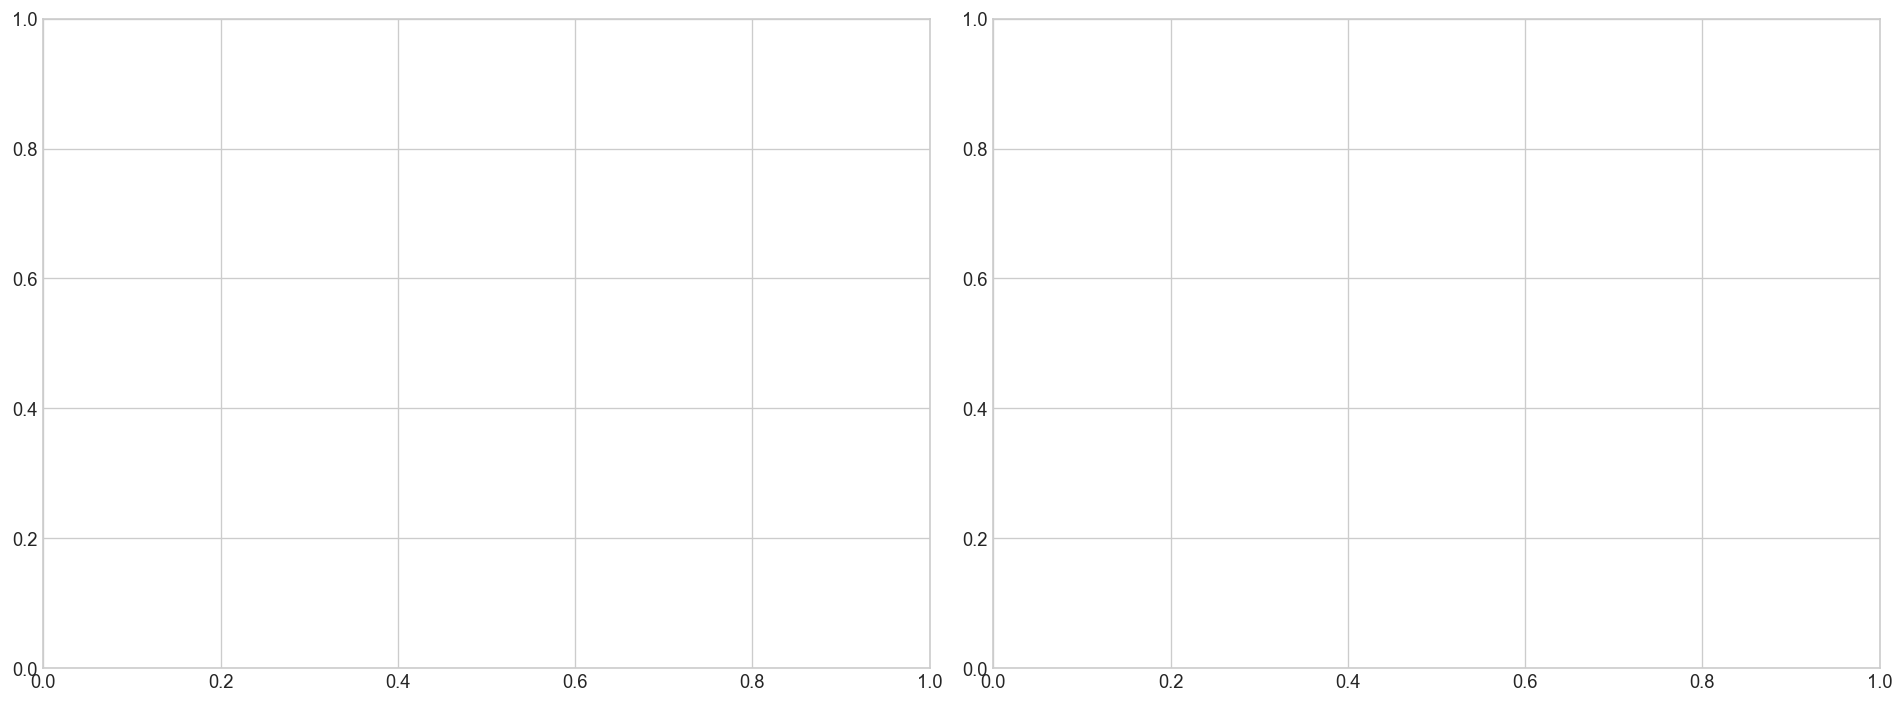


Sensitivity visualization saved: /Users/tuta/Desktop/busa693-clubpiscine/reports/figures/optimization_sensitivity.png


In [11]:
# ===================================================================
# SENSITIVITY ANALYSIS: Bootstrap Uncertainty in Optimal Allocation
# ===================================================================
# Sample coefficients from bootstrap CIs and re-optimize to get allocation RANGES

np.random.seed(42)
N_BOOT = 200

boot_allocations = {ch: [] for ch in CHANNELS}
boot_responses = []

eff_total_for_boot = eff_df[eff_df['product'] == 'Total Revenue'].set_index('channel')

for i in range(N_BOOT):
    # Sample coefficients from bootstrap distribution (uniform within CI)
    sampled_coefs = {}
    for ch in CHANNELS:
        row = eff_total_for_boot.loc[ch]
        ci_lo = max(float(row['marginal_ci_lo']), 0)  # Non-negative constraint
        ci_hi = max(float(row['marginal_ci_hi']), 0)
        coef_key = f'media_{ch}_saturated'
        base_coef = coefs_orig.get(coef_key, 0.0)

        if ci_hi > ci_lo and base_coef > 0:
            # Scale coefficient proportionally to sampled marginal
            base_marginal = float(row['marginal_per_1000'])
            if base_marginal > 0:
                sampled_marginal = np.random.uniform(ci_lo, ci_hi)
                scale_factor = sampled_marginal / base_marginal
            else:
                scale_factor = np.random.uniform(0.5, 1.5)
            sampled_coefs[coef_key] = base_coef * scale_factor
        else:
            sampled_coefs[coef_key] = 0.0

    # Build sampled response functions
    sampled_rfuncs = {}
    for ch in CHANNELS:
        ch_data = sat_curves_df[sat_curves_df['channel'] == ch].sort_values('spend')
        spend_pts = ch_data['spend'].values
        sat_pts = ch_data['saturation'].values
        coef_key = f'media_{ch}_saturated'
        rev_pts = sampled_coefs[coef_key] * sat_pts
        sampled_rfuncs[ch] = interp1d(spend_pts, rev_pts, kind='cubic',
                                       bounds_error=False, fill_value=(rev_pts[0], rev_pts[-1]))

    # Re-optimize with sampled functions
    try:
        alloc_i, res_i = optimize_budget_constrained(
            TOTAL_MONTHLY_BUDGET, CHANNELS, sampled_rfuncs, spend_bounds,
            CURRENT_SPEND, BUSINESS_CONSTRAINTS, eff_total_for_boot
        )
        if res_i.success:
            for ch in CHANNELS:
                boot_allocations[ch].append(alloc_i[ch])
            boot_responses.append(total_response([alloc_i[ch] for ch in CHANNELS],
                                                  CHANNELS, sampled_rfuncs))
    except:
        pass

# Report allocation ranges
print('=' * 110)
print('  SENSITIVITY ANALYSIS: Allocation Ranges from Bootstrap (200 samples)')
print('=' * 110)
print(f'{"Channel":25s} {"Point Est":>12s} {"5th %ile":>12s} {"Median":>12s} {"95th %ile":>12s} {"Range":>15s}')
print('-' * 85)

for ch in CHANNELS:
    vals = np.array(boot_allocations[ch])
    if len(vals) > 0:
        p5, p50, p95 = np.percentile(vals, [5, 50, 95])
        point = optimal_alloc[ch]
        print(f'{CHANNEL_LABELS[ch]:25s} ${point:>10,.0f} ${p5:>10,.0f} ${p50:>10,.0f} ${p95:>10,.0f} '
              f'[${p5/1000:.0f}K-${p95/1000:.0f}K]')

if len(boot_responses) > 0:
    resp_arr = np.array(boot_responses)
    print(f'\nOptimal response range: ${np.percentile(resp_arr, 5):,.0f} - ${np.percentile(resp_arr, 95):,.0f}')
    print(f'Median response: ${np.median(resp_arr):,.0f}')
    print(f'(Point estimate: ${optimal_response:,.0f})')

    # Compute realistic lift range
    lift_lo = (np.percentile(resp_arr, 5) - current_response) / abs(current_response) * 100
    lift_hi = (np.percentile(resp_arr, 95) - current_response) / abs(current_response) * 100
    print(f'\nLift range: {lift_lo:+.1f}% to {lift_hi:+.1f}%')

print('\nNOTE: These ranges reflect estimation uncertainty only.')
print('      True uncertainty is larger due to model specification choices.')

# Save sensitivity results visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Allocation distributions (boxplot)
ax1 = axes[0]
active_channels = [ch for ch in CHANNELS if len(boot_allocations[ch]) > 0 and np.std(boot_allocations[ch]) > 100]
if active_channels:
    data_to_plot = [np.array(boot_allocations[ch])/1000 for ch in active_channels]
    labels_plot = [CHANNEL_LABELS[ch].split('(')[0].strip()[:12] for ch in active_channels]
    bp = ax1.boxplot(data_to_plot, labels=labels_plot, patch_artist=True)
    for patch, color in zip(bp['boxes'], plt.cm.Set3(np.linspace(0, 1, len(active_channels)))):
        patch.set_facecolor(color)
    ax1.set_ylabel('Monthly Allocation ($K)')
    ax1.set_title('Allocation Uncertainty (Bootstrap)', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)

# Panel 2: Response distribution
ax2 = axes[1]
if len(boot_responses) > 0:
    ax2.hist(np.array(boot_responses)/1000, bins=30, color='#3498db', alpha=0.7, edgecolor='white')
    ax2.axvline(current_response/1000, color='red', linestyle='--', linewidth=2, label='Current')
    ax2.axvline(optimal_response/1000, color='green', linestyle='--', linewidth=2, label='Point estimate')
    ax2.set_xlabel('Monthly Media Response ($K)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Response Distribution Under Uncertainty', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(figures_path / 'optimization_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSensitivity visualization saved: {figures_path / "optimization_sensitivity.png"}')

---
## 3. Executive Summary

In [12]:
# ===================================================================
# EXECUTIVE SUMMARY
# ===================================================================
print('=' * 110)
print('  EXECUTIVE SUMMARY: MEDIA BUDGET OPTIMIZATION')
print('  Based on Two-Stage Non-Negative Ridge Model (NB06B) with confidence ratings')
print('=' * 110)
print()

print(f'{"Channel":25s} {"Current/mo":>12s} {"Recommended":>14s} {"Change":>9s} {"ROAS":>7s} {"Confidence":>12s} {"Action":>12s}')
print('-' * 100)

summary_rows = []
for ch in CHANNELS:
    cur = CURRENT_SPEND[ch]
    rec = optimal_alloc[ch]
    change_pct = (rec - cur) / cur * 100 if cur > 0 else 0
    roas = float(eff_total.loc[ch, 'roas'])
    conf = str(eff_total.loc[ch, 'confidence'])

    if change_pct > 10: action = 'INCREASE'
    elif change_pct < -10: action = 'DECREASE'
    else: action = 'MAINTAIN'

    print(f'{CHANNEL_LABELS[ch]:25s} ${cur:>10,.0f} ${rec:>12,.0f} {change_pct:>+8.0f}% {roas:>6.1f}x {conf:>12s} {action:>12s}')
    summary_rows.append({
        'channel': CHANNEL_LABELS[ch], 'current': cur, 'recommended': rec,
        'change_pct': change_pct, 'roas': roas, 'confidence': conf, 'action': action,
    })

print('-' * 100)
print(f'{"TOTAL":25s} ${TOTAL_MONTHLY_BUDGET:>10,.0f} ${sum(optimal_alloc.values()):>12,.0f}')
print()

print('KEY METRICS:')
print(f'  Model fit R² (full):          {model_params["r2"]:.3f}')
print(f'  R² seasonal (Stage 1):        {model_params["r2_s1"]:.3f}')
print(f'  R² media (Stage 2):           {model_params["r2_s2"]:.3f}')
print(f'  Media share of revenue:       {model_params["media_share_pct"]:.1f}%')
print(f'  Seasonal share of revenue:    {model_params.get("seasonal_share_pct", 0):.1f}%')
print(f'  Lift from reallocation:       {lift_pct:+.1f}%')
print()
print('IMPORTANT CAVEATS:')
print('  - Based on 36 monthly observations — results are DIRECTIONAL, not precise')
print('  - Two-stage model: seasonality removed first, then media effects estimated')
print(f'  - Only {len(sig_channels)} of 7 channels are statistically significant: {sig_channels}')
print('  - Channels with negative ROAS (radio, panneaux, digital flyers) are')
print('    held near minimum spend — their true effect may be zero, not negative')
print('  - Recommendations should be validated with controlled budget experiments')

summary_df = pd.DataFrame(summary_rows)

  EXECUTIVE SUMMARY: MEDIA BUDGET OPTIMIZATION
  Based on Two-Stage Non-Negative Ridge Model (NB06B) with confidence ratings

Channel                     Current/mo    Recommended    Change    ROAS   Confidence       Action
----------------------------------------------------------------------------------------------------
Television                $   109,693 $      80,000      -27%    4.5x         HIGH     DECREASE
Radio                     $    60,202 $      54,182      -10%    0.0x         NONE     DECREASE
Panneaux (Outdoor)        $     8,125 $       7,312      -10%    0.0x         NONE     MAINTAIN
Social Media              $    22,984 $      18,243      -21%   16.3x       MEDIUM     DECREASE
Preroll (Video)           $    25,066 $      31,343      +25%   27.7x         HIGH     INCREASE
Web Banners               $    22,989 $      20,000      -13%   12.2x       MEDIUM     DECREASE
Digital Flyers            $    12,404 $      11,164      -10%    0.0x         NONE     MAINTAIN
---

In [13]:
# ===================================================================
# SAVE OUTPUTS
# ===================================================================
opt_df.to_csv(processed_path / 'mmm_optimization_results.csv', index=False)
scenario_df.to_csv(processed_path / 'mmm_scenario_analysis.csv', index=False)
summary_df.to_csv(processed_path / 'mmm_executive_summary.csv', index=False)

mmm_output = {
    'source': 'NB07 (Two-Stage Non-Negative Ridge from NB06B)',
    'created': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'model_performance': {
        'model_type': model_params.get('model_type', 'two_stage_ridge'),
        'r2_full': model_params['r2'],
        'r2_seasonal_s1': model_params['r2_s1'],
        'r2_media_s2': model_params['r2_s2'],
        'media_share_pct': model_params['media_share_pct'],
        'seasonal_share_pct': model_params.get('seasonal_share_pct', 0),
    },
    'optimization': {
        'current_response': float(current_response),
        'optimal_response': float(optimal_response),
        'lift_pct': float(lift_pct),
        'current_allocation': {ch: float(v) for ch, v in CURRENT_SPEND.items()},
        'optimal_allocation': {ch: float(v) for ch, v in optimal_alloc.items()},
    },
}
with open(processed_path / 'mmm_final_output.json', 'w') as f:
    json.dump(mmm_output, f, indent=2)

print('Saved all outputs:')
print(f'  {processed_path / "mmm_optimization_results.csv"}')
print(f'  {processed_path / "mmm_scenario_analysis.csv"}')
print(f'  {processed_path / "mmm_executive_summary.csv"}')
print(f'  {processed_path / "mmm_final_output.json"}')

Saved all outputs:
  /Users/tuta/Desktop/busa693-clubpiscine/data/processed/mmm_optimization_results.csv
  /Users/tuta/Desktop/busa693-clubpiscine/data/processed/mmm_scenario_analysis.csv
  /Users/tuta/Desktop/busa693-clubpiscine/data/processed/mmm_executive_summary.csv
  /Users/tuta/Desktop/busa693-clubpiscine/data/processed/mmm_final_output.json


In [14]:
print('=' * 80)
print('  NOTEBOOK 07 — BUDGET OPTIMIZATION: COMPLETE')
print('=' * 80)
print()
print('PIPELINE:')
print('  NB06B Stage 1 (Seasonal)    → Baseline revenue (89.5% of total)')
print('  NB06B Stage 2 (Media)       → Channel ROAS + effectiveness (non-neg) ★')
print('  NB07 (This notebook)        → Budget allocation + scenarios')
print()
print('KEY RESULTS:')
print(f'  Media share of revenue:     {model_params["media_share_pct"]:.1f}%')
print(f'  Significant channels:       {sig_channels}')
print(f'  Optimization lift:          {lift_pct:+.1f}%')
print(f'  Current monthly budget:     ${TOTAL_MONTHLY_BUDGET:,.0f}')
print(f'  Optimal monthly budget:     ${sum(optimal_alloc.values()):,.0f}')

  NOTEBOOK 07 — BUDGET OPTIMIZATION: COMPLETE

PIPELINE:
  NB06B Stage 1 (Seasonal)    → Baseline revenue (89.5% of total)
  NB06B Stage 2 (Media)       → Channel ROAS + effectiveness (non-neg) ★
  NB07 (This notebook)        → Budget allocation + scenarios

KEY RESULTS:
  Media share of revenue:     10.9%
  Significant channels:       ['television', 'preroll']
  Optimization lift:          -7.3%
  Current monthly budget:     $261,464
  Optimal monthly budget:     $222,244
